In [14]:
# Installing Cudnn
!apt-cache policy c

# Install latest version
!apt install --allow-change-held-packages libcudnn8

# Export env variables
!export PATH=/usr/local/cuda-11.4/bin${PATH:+:${PATH}}
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/lib64:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/include:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/usr/local/cuda/extras/CUPTI/lib64

N: Unable to locate package c
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libcudnn8 is already the newest version (8.9.7.29-1+cuda12.2).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [1]:
import os, glob, shutil, zipfile, gdown
import random, time, math, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn import metrics as skmetrics

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, regularizers, callbacks, optimizers, losses

import tensorboard as tb

# metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
#original Link
# https://drive.google.com/file/d/19RFT4McuE7TblyjIkBTx8O8h7dmNOp3B/view?usp=sharing

# Global Variables
FILE_ID = "19RFT4McuE7TblyjIkBTx8O8h7dmNOp3B"
height, width = 128, 128
BATCH_SIZE=512

In [3]:
# Utility Function

# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

# function to unzip the file
def unzip_file_shutil(zip_path, extract_path):
    try:
        os.makedirs(extract_path, exist_ok=True)
        shutil.unpack_archive(zip_path, extract_path)
        print(f"Successfully extracted to {extract_path}")
    except Exception as e:
        print(f"Error extracting file: {e}")

def deleteLogs(log_path=""):

    if not log_path:
        log_path = os.path.join(os.getcwd(), "logs")
    try:
        shutil.rmtree(log_path)
        print(f"Deleted logs from {log_path}")
    except Exception as e:
        print(f"Error deleting logs: {e}")

def generate_logs_Folder(logfolderName="", usrTimestamp=True, clear_folder=False):
    currentPath = os.getcwd()

    # clear existing eventLogs if clear_folder is True
    if clear_folder:
        deleteLogs(os.path.join(currentPath, "logs"))

    if not os.path.exists(os.path.join(currentPath, "logs")):
        os.mkdir("logs")

    if logfolderName:
        if usrTimestamp:
            logfolderName = logfolderName + "_" + time.strftime("%Y%m%d-%H%M%S")
        else:
            logfolderName = logfolderName
        logName = os.path.join(currentPath, "logs", logfolderName)
        if not os.path.exists(logName):
            os.mkdir(logName)
    else:
        logName = os.path.join(currentPath, "logs")

    return logName

def generate_logs_Name(fileName, logFormat=".log", clear_folder=False):
    folderName = generate_logs_Folder(fileName, clear_folder=clear_folder)
    fileName = fileName + "_" + time.strftime("%Y%m%d-%H%M%S") + logFormat
    return os.path.join(folderName, fileName)

In [4]:
def download_and_prep_dataset(FILE_ID):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSet_path = os.path.abspath(os.path.join(currentPath, "dataSet/ModelDataSet.zip"))
    extractPath = os.path.abspath(os.path.join(currentPath, "unzipLoc/"))

    # create directory if not exists
    if not os.path.exists(os.path.abspath(os.path.join(currentPath, "dataSet/"))):
        os.mkdir(os.path.abspath(os.path.join(currentPath, "dataSet/")))

    if not os.path.exists(extractPath):
        os.mkdir(extractPath)

    # download the dataset
    if not os.path.exists(dataSet_path):
        download_dataset_from_url(url=url, file_path=dataSet_path)

    # unzip the dataset
    if os.listdir(extractPath) == []:
        unzip_file_shutil(zip_path=dataSet_path, extract_path=extractPath)

    # Load the dataset
    return extractPath

def visualizeDataSize(dataSet, maskDataSet, k=4):
  randIdx = random.sample(range(0, len(dataSet)), k)
  fig, axs = plt.subplots(nrows=k, ncols=2, figsize=(8, 8))
  for i, idx in enumerate(randIdx):
    axs[i, 0].imshow(dataSet[idx])
    axs[i, 1].imshow(maskDataSet[idx])
  plt.tight_layout()
  plt.show()

def preprocess(train_data, val_data, test_data, target_height=128, target_width=128):

    # Data Processing Stage with resizing and rescaling operations
    data_preprocess = keras.Sequential(
        name="data_preprocess",
        layers=[
            layers.Resizing(target_height, target_width),
            layers.Rescaling(1.0/255),
        ]
    )

    # Perform Data Processing on the train, val, test dataset
    train_ds = train_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

CWD:  /content
/content/unzipLoc


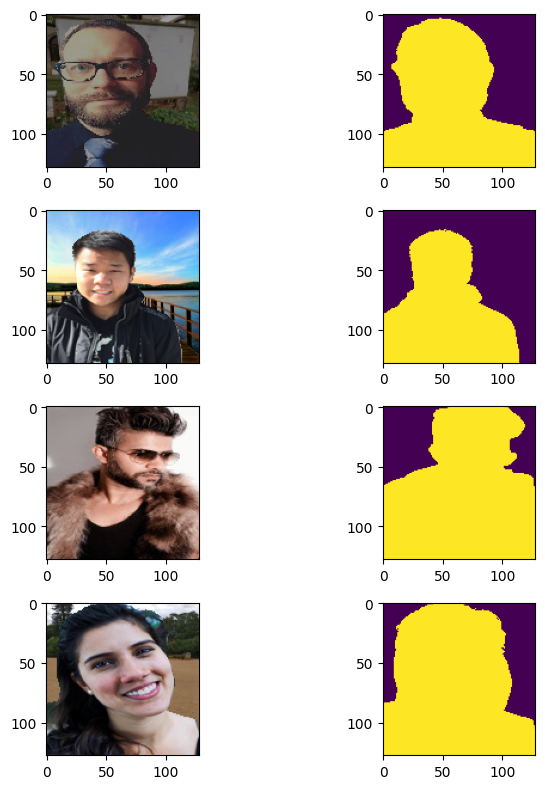

In [5]:
# prepare the Dataset
dl_ext_data_path = download_and_prep_dataset(FILE_ID=FILE_ID)
print(dl_ext_data_path)

## load data
ImgData = np.load(os.path.join(dl_ext_data_path, "img_uint8.npy"))
MaskData = np.load(os.path.join(dl_ext_data_path, "msk_uint8.npy"))

visualizeDataSize(ImgData, MaskData)

MaskData[MaskData > 0] = 1

#### Data Exploration

In [6]:
print("ImgData.shape: ", ImgData.shape)
print("MaskData.shape: ", MaskData.shape)

print(f"IMAGE - pixel Value- Max : {np.max(ImgData)}, Min: {np.min(ImgData)}")
print(f"MASK  - pixel Value- Max : {np.max(MaskData)}, Min: {np.min(MaskData)}")

# Scaling and preparing the data.
yCateg = tf.keras.utils.to_categorical(MaskData)
del MaskData
gc.collect()

ImgData.shape:  (18698, 128, 128, 3)
MaskData.shape:  (18698, 128, 128, 1)
IMAGE - pixel Value- Max : 255, Min: 0
MASK  - pixel Value- Max : 255, Min: 0


18068

In [7]:
print("yCateg.shape: ", yCateg.shape)
print("ImageData.shape: ", ImgData.shape)
XTrain, XTest, yTrain, yTest = train_test_split(ImgData, yCateg, test_size=0.2, random_state=42)

print("XTrain.shape: ", XTrain.shape)
print("yTrain.shape: ", yTrain.shape)
print("XTest.shape: ", XTest.shape)
print("yTest.shape: ", yTest.shape)

del ImgData
del yCateg
gc.collect()

yCateg.shape:  (18698, 128, 128, 2)
ImageData.shape:  (18698, 128, 128, 3)
XTrain.shape:  (14958, 128, 128, 3)
yTrain.shape:  (14958, 128, 128, 2)
XTest.shape:  (3740, 128, 128, 3)
yTest.shape:  (3740, 128, 128, 2)


0

In [9]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

# Clear any logs from previous runs
!rm -rf ./logs/

In [10]:
def fcVgg16_Encoder_decoder_model(inpShape = (128, 128, 3)):
    VGG16 = tf.keras.applications.VGG16(weights="imagenet",
                                        include_top=False,
                                        input_tensor=tf.keras.Input(shape=(128, 128, 3)))
    VGG16.trainable  = False
    x = VGG16(VGG16.input)

    #Decoder
    o = tf.keras.layers.Conv2D( 4096 , ( 7 , 7 ) , activation='relu' , padding='same', name="conv6")(x)
    conv7 = tf.keras.layers.Conv2D( 4096 , ( 1 , 1 ) , activation='relu' , padding='same', name="conv7")(o)
    print(o.shape,conv7.shape)

    ## 4 times upsamping for pool4 layer
    conv7_4 = tf.keras.layers.Conv2DTranspose( 2 , kernel_size=(4,4) ,  strides=(4,4) , use_bias=False)(conv7)

    ## 2 times upsampling for pool411

    pool4 = VGG16.get_layer('block4_pool').output
    pool411 = tf.keras.layers.Conv2D( 2 , ( 1 , 1 ) , activation='relu' , padding='same', name="pool4_11")(pool4)
    pool411_2 = tf.keras.layers.Conv2DTranspose(2 , kernel_size=(2,2) ,  strides=(2,2) , use_bias=False)(pool411)

    pool3 = VGG16.get_layer('block3_pool').output
    pool311 = tf.keras.layers.Conv2D(2 , ( 1 , 1 ) , activation='relu' , padding='same', name="pool3_11")(pool3)
    o = tf.keras.layers.Add(name="add")([pool411_2, pool311])

    print(o.shape,conv7_4.shape)
    o = tf.keras.layers.Add(name="add1")([o, conv7_4 ])
    o = tf.keras.layers.Conv2DTranspose(2 , kernel_size=(8,8) ,  strides=(8,8) , use_bias=False)(o)
    o = tf.keras.layers.Activation('softmax')(o)

    model = tf.keras.Model(VGG16.input, o)

    return model

In [11]:
model = fcVgg16_Encoder_decoder_model()
a = keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file='fcn8.jpeg')

(None, 4, 4, 4096) (None, 4, 4, 4096)
(None, 16, 16, 2) (None, 16, 16, 2)


In [12]:
def diceCoefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

In [13]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=[diceCoefficient])

model.fit(XTrain, yTrain, batch_size=64, epochs=10, validation_data=(XTest, yTest))

Epoch 1/10


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 128, 128, 1), output.shape=(None, 128, 128, 2)